# Great Belt TT stacking 

Set `SHIP_NAME` in the **Run ship** cell and re-run from there.

Ships to choose from:

| Dataset | MMSI | Name | Type | Crossing | Direction | SOG | L × W [m] |
|---|---|---|---|---|---|---|---|
| The Great Belt | 219814000 | Tern Sea | Tanker | 09:07:30 | Southbound | 11.15 | 147 × 22 |
| | 259888000 | Stavfjord | Tanker | 09:13:10 | Southbound | 10.73 | 144 × 23 |
| | 366663000 | Arc Endeavor | Cargo | 09:28:01 | Southbound | 11.92 | 229 × 32 |
| | 232005179 | Resolute Bay | Cargo | 09:29:11 | Northbound | 12.91 | 186 × 28 |
| | 629009770 | Dusk | Tanker | 10:17:56 | Northbound | 10.12 | 244 × 42 |
| | 538004383 | Federal Sutton | Cargo | 10:19:49 | Northbound | 12.51 | 189 × 28 |

In [1]:
%load_ext autoreload
%autoreload 2

import glob
import os
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from src.preprocessing import (
    extract_das_data_npy,
    cable_depth_storebælt,
    load_ais,
    preprocess_ship,
)
from src.tt_stacking import (
    run_stacking_loop,
    assign_y_sign_stacking,
)
from src.config import get_ship

from src.plotting import (
    plot_stacking_vs_ais, 
    plot_stacking_map,
)

c:\Users\Lenovo\miniforge3\envs\das-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Paths 
DATA_DIR      = r"C:\Users\Lenovo\OneDrive - Danmarks Tekniske Universitet\Dokumenter\GitHub\DAS-BOOT-Localisation-of-Signals-in-Distributed-Acoustic-Sensing\data\greatbelt"
CABLE_GEOJSON = r"C:\Users\Lenovo\OneDrive - Danmarks Tekniske Universitet\Dokumenter\GitHub\DAS-BOOT-Localisation-of-Signals-in-Distributed-Acoustic-Sensing\data\cable_info\greatbeltcable.json"
AIS_CSV       = r"C:\Users\Lenovo\OneDrive - Danmarks Tekniske Universitet\Dokumenter\GitHub\DAS-BOOT-Localisation-of-Signals-in-Distributed-Acoustic-Sensing\data\AIS\ais_greatbelt.csv"

# Acquisition 
DX       = 2.035    # m
DT       = 0.0025   # s
OFFSET_M = 1235     # m

# Preprocessing 
BANDPASS_LOW  = 4    # Hz
BANDPASS_HIGH = 100  # Hz
FK_VMIN       = 1400 # m/s
FK_VMAX       = 2000 # m/s
FK_SIGMA      = 50

# Noise reference window (quiet period between ships)
NOISE_START = '094000'
NOISE_END   = '094300'

In [3]:
# setup: file list, AIS, cable depth
file_paths_npy = sorted(glob.glob(DATA_DIR + '/*.npy'))
print(f'Found {len(file_paths_npy)} NPY files')

df_ais = load_ais(AIS_CSV)

depth_interp = cable_depth_storebælt(CABLE_GEOJSON)
print('Setup complete.')

Found 1413 NPY files
AIS: 10302 points,  09:00:00–11:00:00 UTC
Setup complete.


In [4]:
# Run by ship name
SHIP_NAME = 'STAVFJORD'   

ship = get_ship(SHIP_NAME)
print(f"=== {SHIP_NAME}  ({ship['start_time_str']} → {ship['end_time_str']}) ===")
print(f"    dmin={ship['dmin_km']} km,  dmax={ship['dmax_km']} km")

dmin_raw = ship['dmin_km'] - OFFSET_M / 1000.0
dmax_raw = ship['dmax_km'] - OFFSET_M / 1000.0
print('Loading noise reference...')
noise_data, *_ = extract_das_data_npy(
    file_paths_npy, NOISE_START, NOISE_END,
    dmin_km=dmin_raw, dmax_km=dmax_raw,
    dx=DX, dt=DT, offset_m=OFFSET_M,
)

# Preprocess ship data (detrend, normalize, bandpass, fk)
data_proc, time_axis, distances = preprocess_ship(
    ship_cfg       = ship,
    file_paths_npy = file_paths_npy,
    noise_data     = noise_data,
    dmin_km        = ship['dmin_km'],
    dmax_km        = ship['dmax_km'],
    dx=DX, dt=DT, offset_m=OFFSET_M,
    apply_detrend      = True,
    apply_channel_norm = True,
    apply_bp           = True, bp_low=BANDPASS_LOW, bp_high=BANDPASS_HIGH,
    apply_fk           = True, fk_params=dict(vmin=FK_VMIN, vmax=FK_VMAX, sigma=FK_SIGMA),
)

# Runs semblance gridsearch for each window together with Kalman filter
df_stack = run_stacking_loop(
    inv_data       = data_proc,
    time_axis      = time_axis,
    distances      = distances,
    dt             = DT,
    start_time_str = ship['start_time_str'],
    end_time_str   = ship['end_time_str'],
    depth_interp   = depth_interp,
    **ship['stacking_cfg'],
)

print(f'Stacking: {len(df_stack)} windows')
df_stack.head()

=== STAVFJORD  (090910 → 091710) ===
    dmin=4.5 km,  dmax=8.5 km
Loading noise reference...
Loaded 18 files (094000 → 094300),  shape (72000, 1966),  duration 180.0 s
Loaded 48 files (090910 → 091710),  shape (192000, 1966),  duration 480.0 s


Stacking windows: 100%|██████████| 478/478 [21:28<00:00,  2.69s/it]

Stacking: 478 windows


,x_m,y_m,t0_sample,stack_amplitude,pick_idx,ch_idx,x_spread,y_spread,x_median,y_median,...,mahal_sq,mahal_accepted,x_kalman,vx_kalman,y_kalman,vy_kalman,time_center,window_start_idx,window_end_idx,snr
0,6590.000000,1351.000000,451,0.230795,"[754, 752, 749, 747, 745, 743, 740, 738, 736, ...","[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55,...",78.383672,66.513157,6590.000000,1361.000000,...,NaN,True,6527.072545,0.000000,1404.137034,0.000000,2025-11-22 09:09:11+00:00,0,800,5.914641
1,6487.072545,1444.137034,242,0.204022,"[512, 509, 507, 505, 503, 501, 499, 496, 494, ...","[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55,...",14.696938,14.142136,6457.072545,1464.137034,...,47.821785,False,6527.072545,0.000000,1404.137034,0.000000,2025-11-22 09:09:12+00:00,400,1200,5.906129
2,6537.072545,1354.137034,251,0.215051,"[542, 540, 537, 535, 533, 531, 528, 526, 524, ...","[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55,...",54.258640,53.291650,6537.072545,1354.137034,...,0.662555,True,6523.952657,-0.060004,1395.661300,-3.536287,2025-11-22 09:09:13+00:00,800,1600,5.887853
3,6473.892654,1452.125013,356,0.209234,"[622, 620, 618, 615, 613, 611, 609, 607, 605, ...","[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55,...",14.966630,61.644140,6493.892654,1432.125013,...,0.305500,True,6511.887157,-0.496640,1392.026131,-3.576851,2025-11-22 09:09:14+00:00,1200,2000,5.978682
4,6471.390517,1448.449280,260,0.215802,"[526, 524, 521, 519, 517, 515, 513, 511, 508, ...","[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55,...",12.000000,11.661904,6471.390517,1448.449280,...,54.238615,False,6511.390517,-0.496640,1388.449280,-3.576851,2025-11-22 09:09:15+00:00,1600,2400,6.099134


In [5]:
#Assigns y-sign to stacking results based on AIS crossing time 
df_signed, crossing_time = assign_y_sign_stacking(
    df_stack,
    crossing_override = ship['crossing_time_override'],
)
print(f"Crossing: {pd.to_datetime(crossing_time).strftime('%H:%M:%S')} UTC")
print(f'Windows:  {len(df_signed)}')
df_signed.head()

Crossing: 09:13:10 UTC
Windows:  478


,x_m,y_m,t0_sample,stack_amplitude,pick_idx,ch_idx,x_spread,y_spread,x_median,y_median,...,x_kalman,vx_kalman,y_kalman,vy_kalman,time_center,window_start_idx,window_end_idx,snr,y_sign,y_signed
0,6590.000000,1351.000000,451,0.230795,"[754, 752, 749, 747, 745, 743, 740, 738, 736, ...","[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55,...",78.383672,66.513157,6590.000000,1361.000000,...,6527.072545,0.000000,1404.137034,0.000000,2025-11-22 09:09:11+00:00,0,800,5.914641,1.0,1351.000000
1,6487.072545,1444.137034,242,0.204022,"[512, 509, 507, 505, 503, 501, 499, 496, 494, ...","[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55,...",14.696938,14.142136,6457.072545,1464.137034,...,6527.072545,0.000000,1404.137034,0.000000,2025-11-22 09:09:12+00:00,400,1200,5.906129,1.0,1444.137034
2,6537.072545,1354.137034,251,0.215051,"[542, 540, 537, 535, 533, 531, 528, 526, 524, ...","[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55,...",54.258640,53.291650,6537.072545,1354.137034,...,6523.952657,-0.060004,1395.661300,-3.536287,2025-11-22 09:09:13+00:00,800,1600,5.887853,1.0,1354.137034
3,6473.892654,1452.125013,356,0.209234,"[622, 620, 618, 615, 613, 611, 609, 607, 605, ...","[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55,...",14.966630,61.644140,6493.892654,1432.125013,...,6511.887157,-0.496640,1392.026131,-3.576851,2025-11-22 09:09:14+00:00,1200,2000,5.978682,1.0,1452.125013
4,6471.390517,1448.449280,260,0.215802,"[526, 524, 521, 519, 517, 515, 513, 511, 508, ...","[0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55,...",12.000000,11.661904,6471.390517,1448.449280,...,6511.390517,-0.496640,1388.449280,-3.576851,2025-11-22 09:09:15+00:00,1600,2400,6.099134,1.0,1448.449280


c:\Users\Lenovo\OneDrive - Danmarks Tekniske Universitet\Dokumenter\GitHub\DAS-BOOT-Localisation-of-Signals-in-Distributed-Acoustic-Sensing\src\plotting.py:199: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


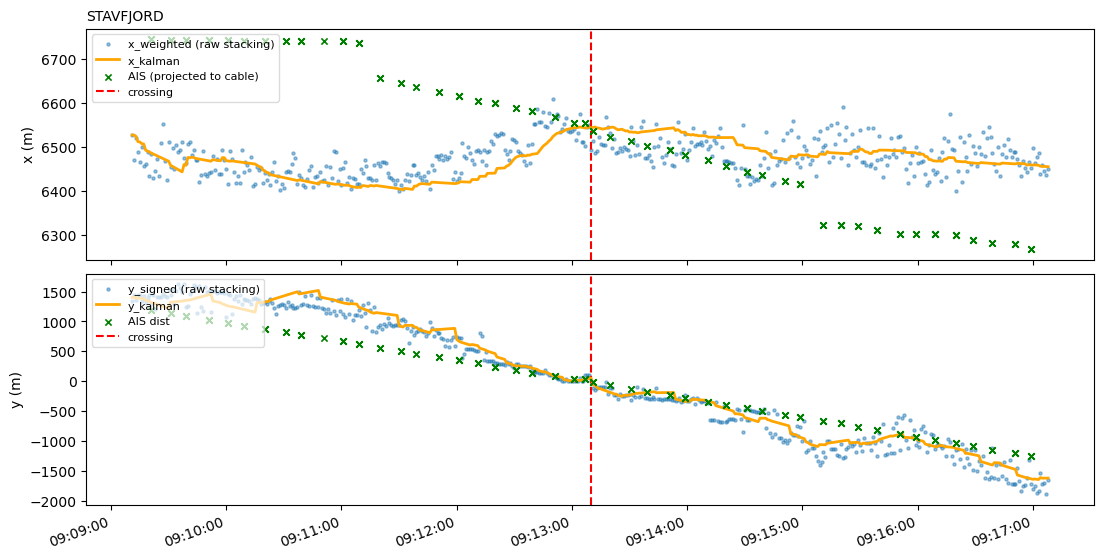

In [6]:
df_ais_ship = df_ais[df_ais['Name'] == SHIP_NAME].copy()

fig = plot_stacking_vs_ais(
    df_signed          = df_signed,
    df_ais             = df_ais_ship,
    crossing_time      = crossing_time,
    cable_geojson_path = CABLE_GEOJSON,
    ship_name          = SHIP_NAME,
)
plt.show()

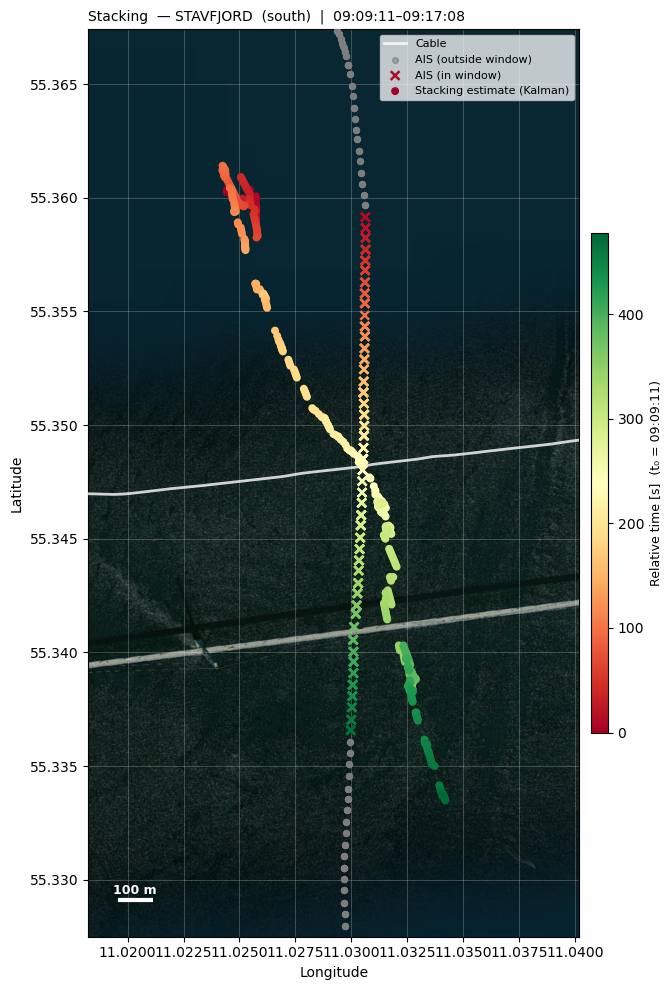

In [8]:
df_ais_ship = df_ais[df_ais['Name'] == SHIP_NAME].copy()
fig = plot_stacking_map(
    df_signed          = df_signed,
    df_ais             = df_ais_ship,   
    crossing_time      = crossing_time,
    cable_geojson_path = CABLE_GEOJSON,
    ship_name          = SHIP_NAME,
    bound              = ship['bound'],
    show_kalman        = True,  # True to show Kalman-smoothed estimates instead of raw stacking
)
plt.show()